# 3.PyTorch神经网络工具箱

## 3.2 实现神经网络实例

In [1]:
import numpy as np 
import torch
from torchvision.datasets import mnist
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch import nn

# 定义一些超参数
train_batch_size = 64
test_batch_size = 128
learning_rate = 0.01
num_epoches = 20
lr =0.01
momentum = 0.5

# 下载数据并对数据进行预处理
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize([0.5], [0.5])]) # 定义预处理函数，依次存放在Compose中
train_dataset = mnist.MNIST('./data', train=True, transform=transform, download=True)
test_dataset = mnist.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle = False)

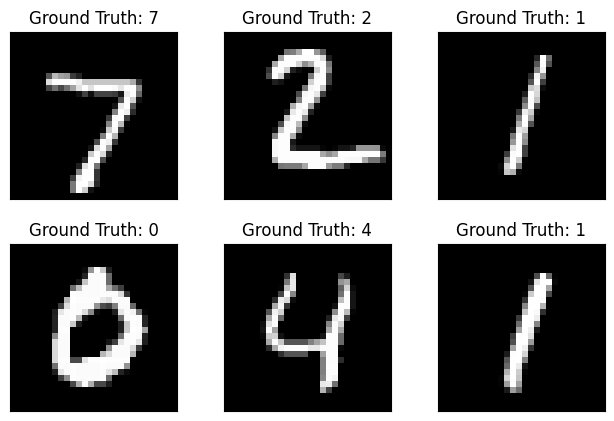

In [2]:
# 可视化源数据
import matplotlib.pyplot as plt

# Jupyter专用命令：让图片直接显示在代码下方
%matplotlib inline

examples = enumerate(test_loader) # 给测试集数据添加索引
batch_idx, (example_data, example_targets) = next(examples) # 

fig = plt.figure()

for i in range(6): # 循环画六次
    plt.subplot(2, 3, i+1) # 把画布分成 2行3列，当前画第i+1个位置
    plt.tight_layout() # 自动调整布局
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none') # 显示第i张图片，灰度图像显示，无插值模糊
    plt.title(f'Ground Truth: {example_targets[i]}') # 给每张图片增加标题——这张图片显示多少
    plt.xticks([]) # 隐藏x轴坐标
    plt.yticks([]) # 隐藏y轴坐标

In [3]:
# 构建模型
class Net(nn.Module):
    '''使用sequential构建网络，Sequential()函数的功能是将网络的层组合到一起'''
    def __init__(self, in_dim, n_hidden_1, n_hidden_2, out_dim):
        super(Net, self).__init__()
        self.layer1 = nn.Sequential(nn.Linear(in_dim, n_hidden_1), nn.BatchNorm1d(n_hidden_1))
        self.layer2 = nn.Sequential(nn.Linear(n_hidden_1, n_hidden_2), nn.BatchNorm1d(n_hidden_2))
        self.layer3 = nn.Sequential(nn.Linear(n_hidden_2, out_dim))

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x
    
# 检测是否有可用GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# 实例化网络
model = Net(28 * 28, 300, 100, 10)
model.to(device)
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)


In [ ]:
# 训练模型
losses = []
acces = []
eval_losses = []
eval_acces = []

for epoch in range(num_epoches):
    train_loss = 0
    train_acc = 0
    model.train()

    # 动态修改参数学习率
    if epoch > 0 and epoch%5==0:
        optimizer.param_groups[0]['lr']*=0.1
    
    for img, label in train_loader:
        img=img.to(device)
        label = label.to(device)
        img = img.view(img.size(0), -1)
        # 前向传播
        out = model(img)
        loss = criterion(out, label)
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 记录误差
        train_loss += loss.item()
        _, pred = out.max(1)
        num_correct = (pred == label).sum().item()
        acc = num_correct / img.shape[0]
        train_acc += acc

    losses.append(train_loss / len(train_loader))
    acces.append(train_acc / len(train_loader))
    # 在测试集上检验效果
    eval_loss = 0
    eval_acc = 0

    # 将模型改为预测模式
    model.eval()
    with torch.no_grad():
        for img, label in test_loader:
            img=img.to(device)
            label=label.to(device)
            img = img.view(img.size(0), -1)
            # 前向传播
            out =model(img)
            loss = criterion(out, label)
            # 记录误差
            eval_loss += loss.item()
            # 记录准确率
            _, pred = out.max(1)
            num_correct = (pred == label).sum().item()
            acc = num_correct / img.shape[0]
            eval_acc += acc

    eval_losses.append(eval_loss / len(test_loader))
    eval_acces.append(eval_acc / len(test_loader))
    print(f'epoch: {epoch}, Train Loss:{train_loss / len(train_loader):.4f}, Train Acc: {train_acc / len(train_loader):.4f}, Test Loss: {eval_loss / len(test_loader):.4f}, Test Acc: {eval_acc / len(test_loader):.4f}')

epoch: 0, Train Loss:1.0244, Train Acc: 0.7835, Test Loss: 0.5522, Test Acc: 0.8967
epoch: 1, Train Loss:0.4799, Train Acc: 0.9006, Test Loss: 0.3486, Test Acc: 0.9236
epoch: 2, Train Loss:0.3496, Train Acc: 0.9193, Test Loss: 0.2723, Test Acc: 0.9360
epoch: 3, Train Loss:0.2843, Train Acc: 0.9326, Test Loss: 0.2269, Test Acc: 0.9432
epoch: 4, Train Loss:0.2423, Train Acc: 0.9413, Test Loss: 0.1952, Test Acc: 0.9504
epoch: 5, Train Loss:0.2229, Train Acc: 0.9454, Test Loss: 0.1933, Test Acc: 0.9497
epoch: 6, Train Loss:0.2200, Train Acc: 0.9465, Test Loss: 0.1917, Test Acc: 0.9524
epoch: 7, Train Loss:0.2169, Train Acc: 0.9464, Test Loss: 0.1875, Test Acc: 0.9530


## 3.3如何构建神经网络

### 3.3.1 构建网络层

In [ ]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net4, self).__init__()
        self.conv = torch.nn.Sequential(
            OrderedDict(
                [
                    
                ]
            )
        )